<a href="https://colab.research.google.com/github/UmymaM/ml-dl-cv-fundamentals/blob/main/anomaly-detection/training_autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
import zipfile
import tarfile
import os

In [2]:
!kaggle datasets download -d atulanandjha/lfwpeople


Dataset URL: https://www.kaggle.com/datasets/atulanandjha/lfwpeople
License(s): GNU Lesser General Public License 3.0
100% 232M/232M [00:16<00:00, 14.5MB/s]



In [3]:
zipfile=zipfile.ZipFile('lfwpeople.zip') #unzipping the lfwpeople file
zipfile.extractall()
zipfile.close()

In [4]:
tgz_file_path="/content/lfw-funneled.tgz"
# Directory to extract to
extract_dir="/content/"
with tarfile.open(tgz_file_path, 'r:gz') as tar:
    tar.extractall(path=extract_dir)

/tmp/ipykernel_15104/4035745994.py:5: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_dir)


In [5]:
images=[]
for file in os.listdir('/content/lfw_funneled'):
    file_path = os.path.join('/content/lfw_funneled', file)
    if os.path.isdir(file_path):
        for image in os.listdir(file_path):
          image=os.path.join(file_path,image)
          images.append(image)
    else:
        print(f"Skipping file: {file}")

Skipping file: pairs_08.txt
Skipping file: pairs.txt
Skipping file: pairs_07.txt
Skipping file: pairs_09.txt
Skipping file: pairs_10.txt
Skipping file: pairs_04.txt
Skipping file: pairs_05.txt
Skipping file: pairs_03.txt
Skipping file: pairs_06.txt
Skipping file: pairs_01.txt
Skipping file: pairs_02.txt


In [6]:
for i in range(10):
  print(images[i])

/content/lfw_funneled/Eric_Snow/Eric_Snow_0001.jpg
/content/lfw_funneled/John_Paul_DeJoria/John_Paul_DeJoria_0001.jpg
/content/lfw_funneled/Jim_Parque/Jim_Parque_0001.jpg
/content/lfw_funneled/Thomas_Manger/Thomas_Manger_0001.jpg
/content/lfw_funneled/Marcelo_Bielsa/Marcelo_Bielsa_0001.jpg
/content/lfw_funneled/San_Lan/San_Lan_0001.jpg
/content/lfw_funneled/Joe_Dumars/Joe_Dumars_0001.jpg
/content/lfw_funneled/Joe_Dumars/Joe_Dumars_0002.jpg
/content/lfw_funneled/Spike_Lee/Spike_Lee_0001.jpg
/content/lfw_funneled/Paul_Greengrass/Paul_Greengrass_0001.jpg


In [7]:
!kaggle datasets download -d manjilkarki/deepfake-and-real-images

Dataset URL: https://www.kaggle.com/datasets/manjilkarki/deepfake-and-real-images
License(s): unknown
100% 1.68G/1.68G [01:49<00:00, 16.5MB/s]



In [8]:
import zipfile
with zipfile.ZipFile('deepfake-and-real-images.zip', 'r') as z:
    z.extractall()

In [9]:
fake_images=[]
for file in os.listdir('/content/Dataset/Test/Fake'):
    file_path=os.path.join('/content/Dataset/Test/Fake', file)
    fake_images.append(file_path)

In [10]:
total=len(images)
train_images=images[:int(0.8*total)]
real_test=images[int(0.8*total):]

In [11]:
len(real_test)

2647

In [12]:
test_images=real_test+fake_images
test_labels=[0]*len(real_test)+[1]*len(fake_images)

In [13]:
len(test_images)

8139

In [14]:
from PIL import Image

In [15]:
class ImageDataset(torch.utils.data.Dataset):
  def __init__(self,images,labels,transform=None):
    self.images=images
    self.labels=labels
    self.transform=transform
  def __len__(self):
    return len(self.images)

  def __getitem__(self,idx):
    img=Image.open(self.images[idx]).convert("RGB")
    if self.transform:
      img=self.transform(img)
    if self.labels is not None:
            return img,self.labels[idx]
    return img

In [16]:
import random

In [17]:
transform=transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor()])

In [18]:
train_dataset=ImageDataset(train_images,labels=None,transform=transform)
test_dataset=ImageDataset(test_images,labels=test_labels,transform=transform)

In [19]:
train_loader=DataLoader(train_dataset,batch_size=16,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=16,shuffle=False)

**Autoencoder Class**

In [20]:
from torch.nn.modules.conv import ConvTranspose2d
from torch.nn.modules.activation import ReLU
class ConvAutoencoder(nn.Module):
  def __init__(self):
    super(ConvAutoencoder,self).__init__()
    # encoder
    self.encoder=nn.Sequential(
        # this layer extracts low level features like corners, edges, etc + compresses the image from 64 to 32
        nn.Conv2d(3,32,3,stride=2,padding=1), #3 rgb channels, 32 feature maps
        nn.BatchNorm2d(32),
        nn.LeakyReLU(0.2, True),

        nn.Conv2d(32,64,3,stride=2,padding=1),
        nn.BatchNorm2d(64),
        nn.LeakyReLU(0.2, True),

        nn.Conv2d(64,128,3,stride=2,padding=1),
        nn.BatchNorm2d(128),
        nn.LeakyReLU(0.2, True), #replaced relu w leakyrelu

        nn.Conv2d(128, 256, 3, stride=2, padding=1),  # added a fourth layer and batch normalization
        nn.BatchNorm2d(256),
        nn.LeakyReLU(0.2, True),)    #image compressed from 64 to 8
    # decoder
    self.decoder=nn.Sequential(
        nn.ConvTranspose2d(256, 128, 3, stride=2, padding=1, output_padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(True),
        nn.ConvTranspose2d(128,64,3,stride=2,padding=1,output_padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(True),
        nn.ConvTranspose2d(64,32,3,stride=2,padding=1,output_padding=1),
        nn.BatchNorm2d(32),
        nn.ReLU(True),
        nn.ConvTranspose2d(32,3,3,stride=2,padding=1,output_padding=1),
        nn.Sigmoid())
  def forward(self,x):
    bottleneck=self.encoder(x)
    output=self.decoder(bottleneck)
    return output

In [21]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [22]:
model=ConvAutoencoder().to(device)
criterion=nn.MSELoss()
optimizer=optim.Adam(model.parameters(),lr=0.001)

**Training**

In [23]:
for epoch in range(30):
  model.train()
  total_loss=0
  for images in train_loader:
    images=images.to(device)
    outputs=model(images)
    loss=criterion(outputs,images)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    total_loss+=loss.item()
  print(f"Epoch: {epoch+1}, Loss: {total_loss/len(train_loader):.5f}")

Epoch: 1, Loss: 0.01010
Epoch: 2, Loss: 0.00465
Epoch: 3, Loss: 0.00374
Epoch: 4, Loss: 0.00333
Epoch: 5, Loss: 0.00299
Epoch: 6, Loss: 0.00278
Epoch: 7, Loss: 0.00262
Epoch: 8, Loss: 0.00239
Epoch: 9, Loss: 0.00233
Epoch: 10, Loss: 0.00217
Epoch: 11, Loss: 0.00213
Epoch: 12, Loss: 0.00196
Epoch: 13, Loss: 0.00189
Epoch: 14, Loss: 0.00181
Epoch: 15, Loss: 0.00177
Epoch: 16, Loss: 0.00175
Epoch: 17, Loss: 0.00170
Epoch: 18, Loss: 0.00166
Epoch: 19, Loss: 0.00166
Epoch: 20, Loss: 0.00160
Epoch: 21, Loss: 0.00160
Epoch: 22, Loss: 0.00155
Epoch: 23, Loss: 0.00150
Epoch: 24, Loss: 0.00147
Epoch: 25, Loss: 0.00144
Epoch: 26, Loss: 0.00141
Epoch: 27, Loss: 0.00143
Epoch: 28, Loss: 0.00136
Epoch: 29, Loss: 0.00136
Epoch: 30, Loss: 0.00133


In [24]:
model.eval()
errors=[]
with torch.no_grad():
  for batch in test_loader:
    if isinstance(batch,list) or isinstance(batch,tuple):
      images=batch[0].to(device)
    else:
      images=batch.to(device)
    output=model(images)
    loss=torch.mean((images-output)**2,dim=[1,2,3])
    errors.extend(loss.cpu().numpy())
errors=np.array(errors)

In [25]:
real_errors=errors[:len(real_test)]
fake_errors=errors[len(real_test):]

In [26]:
fake_errors

array([0.00238934, 0.00106416, 0.00188992, ..., 0.00088372, 0.00030158,
       0.00076746], dtype=float32)

In [27]:
# threshold=real_errors.mean()+2*real_errors.std() #low precision and f1score
# threshold = np.percentile(real_errors, 85)
#^ Precision: 0.7948320413436692, Recall: 0.28004369992716677, f1 Score: 0.41416453480543963
# threshold=real_errors.mean()+1*real_errors.std()
#^ Precision: 0.8043217286914766, Recall: 0.24399126001456664, f1 Score: 0.37440625873148925
# threshold=real_errors.mean()+0.75*real_errors.std()
#Precision: 0.789213260761999, Recall: 0.29042243262927897, f1 Score: 0.424597364568082
threshold=real_errors.mean()+0.5*real_errors.std()
#^ Precision: 0.7658971243418388, Recall: 0.34431900946831756, f1 Score: 0.4750659464891345
print("Threshold:", threshold)

Threshold: 0.0012473038


In [28]:
y_pred=(errors>threshold).astype(int) #1for fake, 0for real
y_true=np.array(test_labels)

In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print(f"Precision: {precision_score(y_true,y_pred)}\nRecall: {recall_score(y_true,y_pred)}\nf1 Score: {f1_score(y_true,y_pred)}")

Precision: 0.7670856245090337
Recall: 0.3556081573197378
f1 Score: 0.48594177656133364


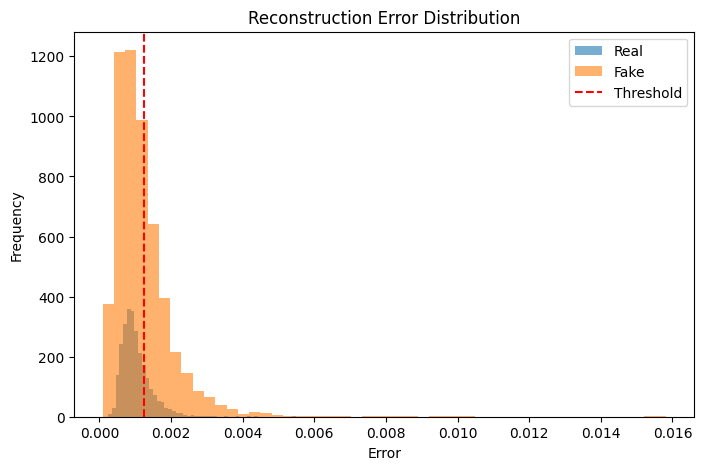

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(real_errors, bins=50, alpha=0.6, label="Real")
plt.hist(fake_errors, bins=50, alpha=0.6, label="Fake")

plt.axvline(threshold, color='red', linestyle='--', label='Threshold')

plt.legend()
plt.title("Reconstruction Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")

plt.show()